# Exploration phase (**optional**)

In this exploration phase we will visualize some features of your dataset to help you make more informed decisitions in case you want to **adapt the default parameters** to your dataset.

You can always skip this part and go with the default parameters but if you want to have a classifier as efficient as possible you should consider spending five minutes running this analysis.

## 1.1 Distribution of classes
**Relevant parameters:** `use_class_weights`

We can visualize the distributions of the classes to check is the dataset is highly imbalanced.

In [7]:
import os
import matplotlib.pylab as plt
from tqdm import tqdm
from planktonclass import paths, config
from planktonclass.data_utils import load_image, load_data_splits, augment, load_class_names, create_data_splits
import numpy as np
from collections import Counter

from pathlib import Path
from planktonclass import config, paths

def find_project_config(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start, start.parent]
    for root in candidates:
        conf_path = root / 'config.yaml'
        if conf_path.exists():
            return conf_path
    for root in [start, *start.parents]:
        conf_path = root / 'config.yaml'
        if conf_path.exists():
            return conf_path
    raise FileNotFoundError('Could not find config.yaml in the current project. Start Jupyter in the project root or its notebooks folder.')

CONF_PATH = find_project_config()
PROJECT_DIR = CONF_PATH.parent
config.set_config_path(str(CONF_PATH))
paths.CONF = config.get_conf_dict()
print(f"Using project config: {os.path.relpath(CONF_PATH, Path.cwd())}")

CONF = config.get_conf_dict()
splits_dir = paths.get_splits_dir()

if 'train.txt' not in os.listdir(splits_dir):
    if not CONF['dataset']['split_ratios']:
        if CONF['training']['use_validation'] and CONF['training']['use_test']:
            split_ratios = [0.7, 0.15, 0.15]
        elif CONF['training']['use_validation'] and (not CONF['training']['use_test']):
            split_ratios = [0.9, 0.1, 0]
        else:
            split_ratios = [1, 0, 0]
    else:
        split_ratios = CONF['dataset']['split_ratios']
    create_data_splits(
        splits_dir=splits_dir,
        im_dir=paths.get_images_dir(),
        split_ratios=split_ratios,
    )

X_train, y_train = load_data_splits(splits_dir=splits_dir, im_dir=paths.get_images_dir(), split_name='train')
X_test, y_test = load_data_splits(splits_dir=splits_dir, im_dir=paths.get_images_dir(), split_name='test')
X_val, y_val = load_data_splits(splits_dir=splits_dir, im_dir=paths.get_images_dir(), split_name='val')
class_names = load_class_names(splits_dir=splits_dir)


2026-03-31 18:19:51 - planktonclass.data_utils - INFO - [data] Loading train split
2026-03-31 18:19:51 - planktonclass.data_utils - INFO - [data] Loading test split
2026-03-31 18:19:51 - planktonclass.data_utils - INFO - [data] Loading val split
2026-03-31 18:19:51 - planktonclass.data_utils - INFO - [data] Loading class names


Using project config: ..\config.yaml


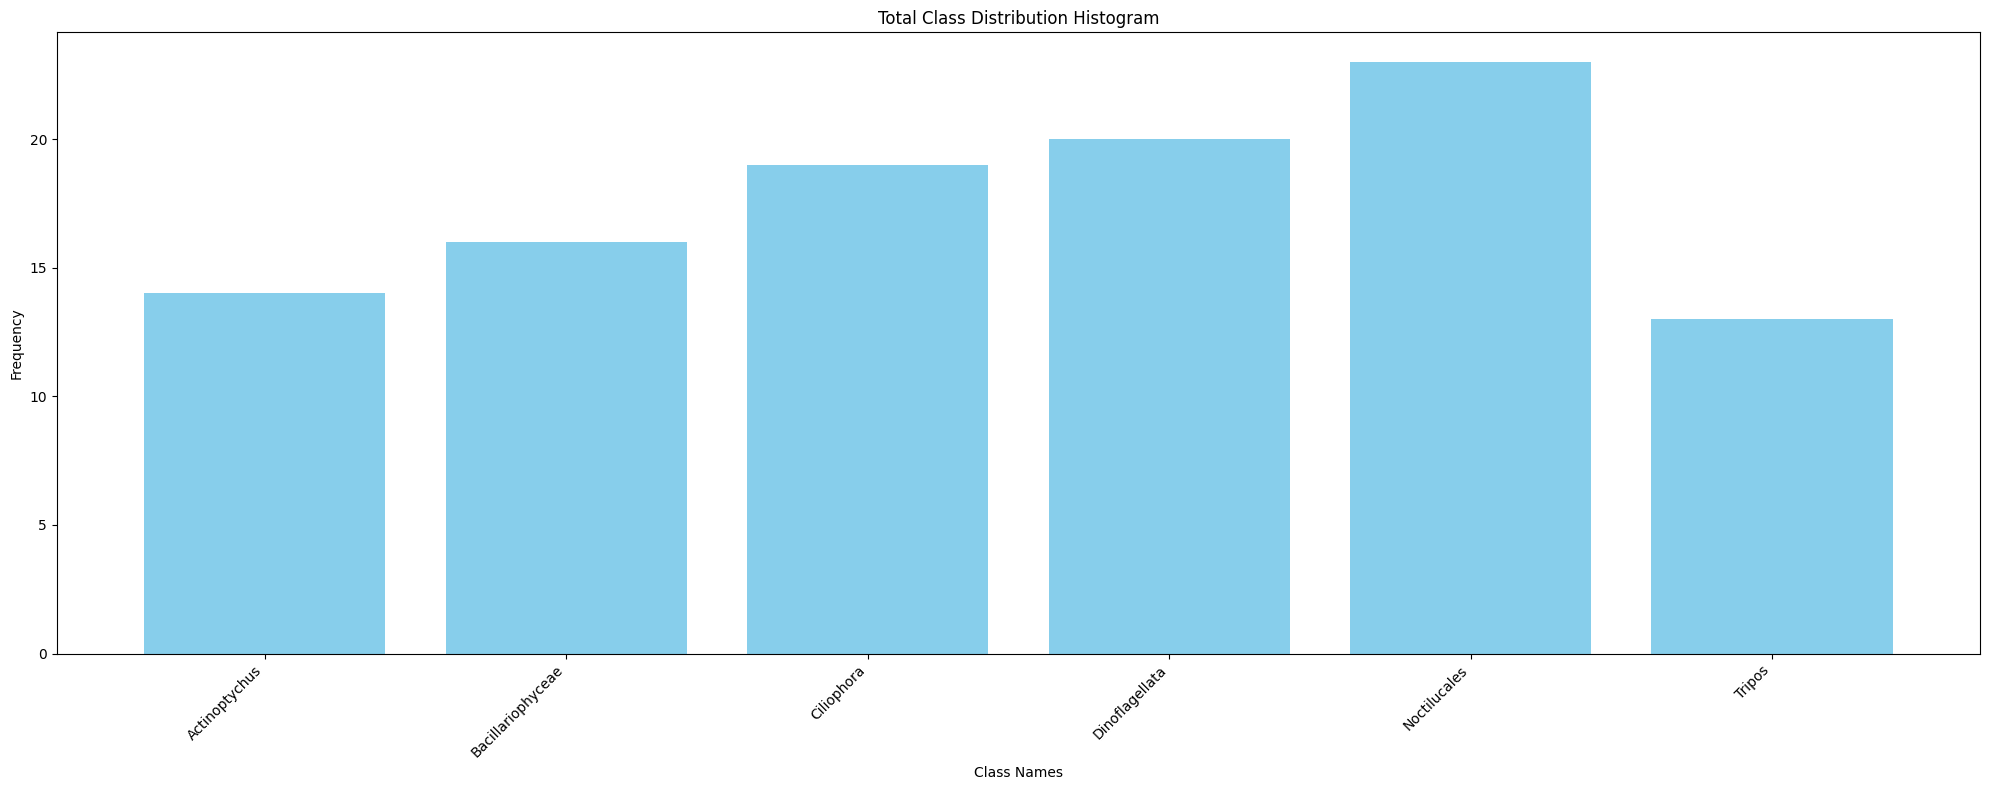

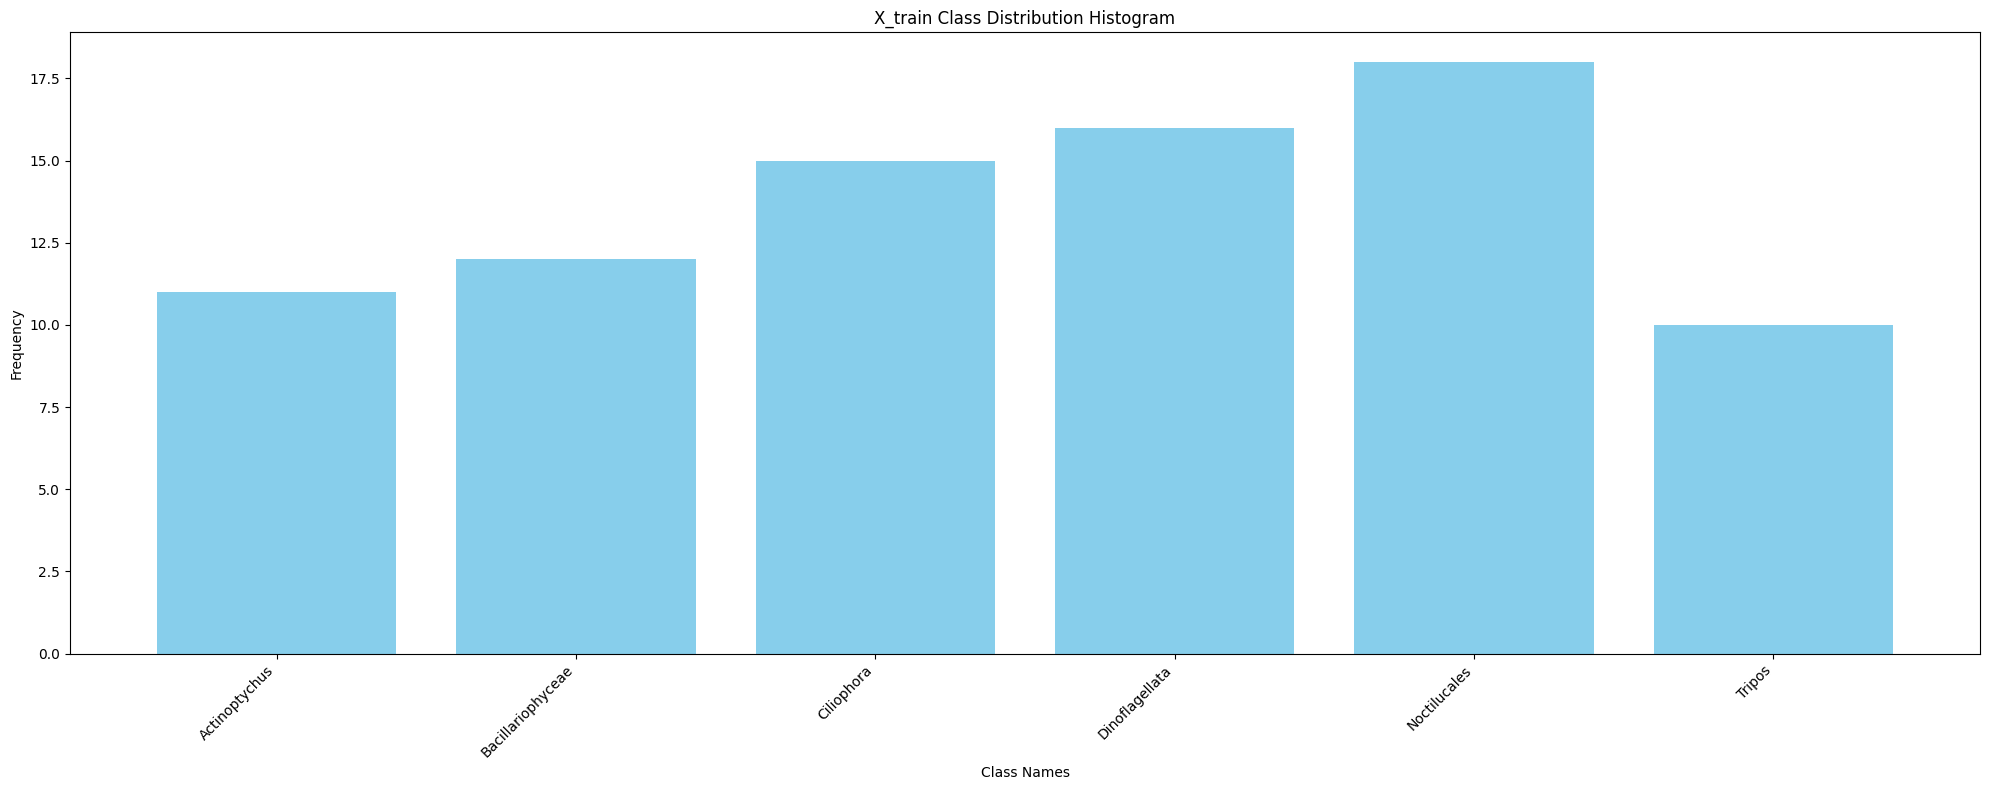

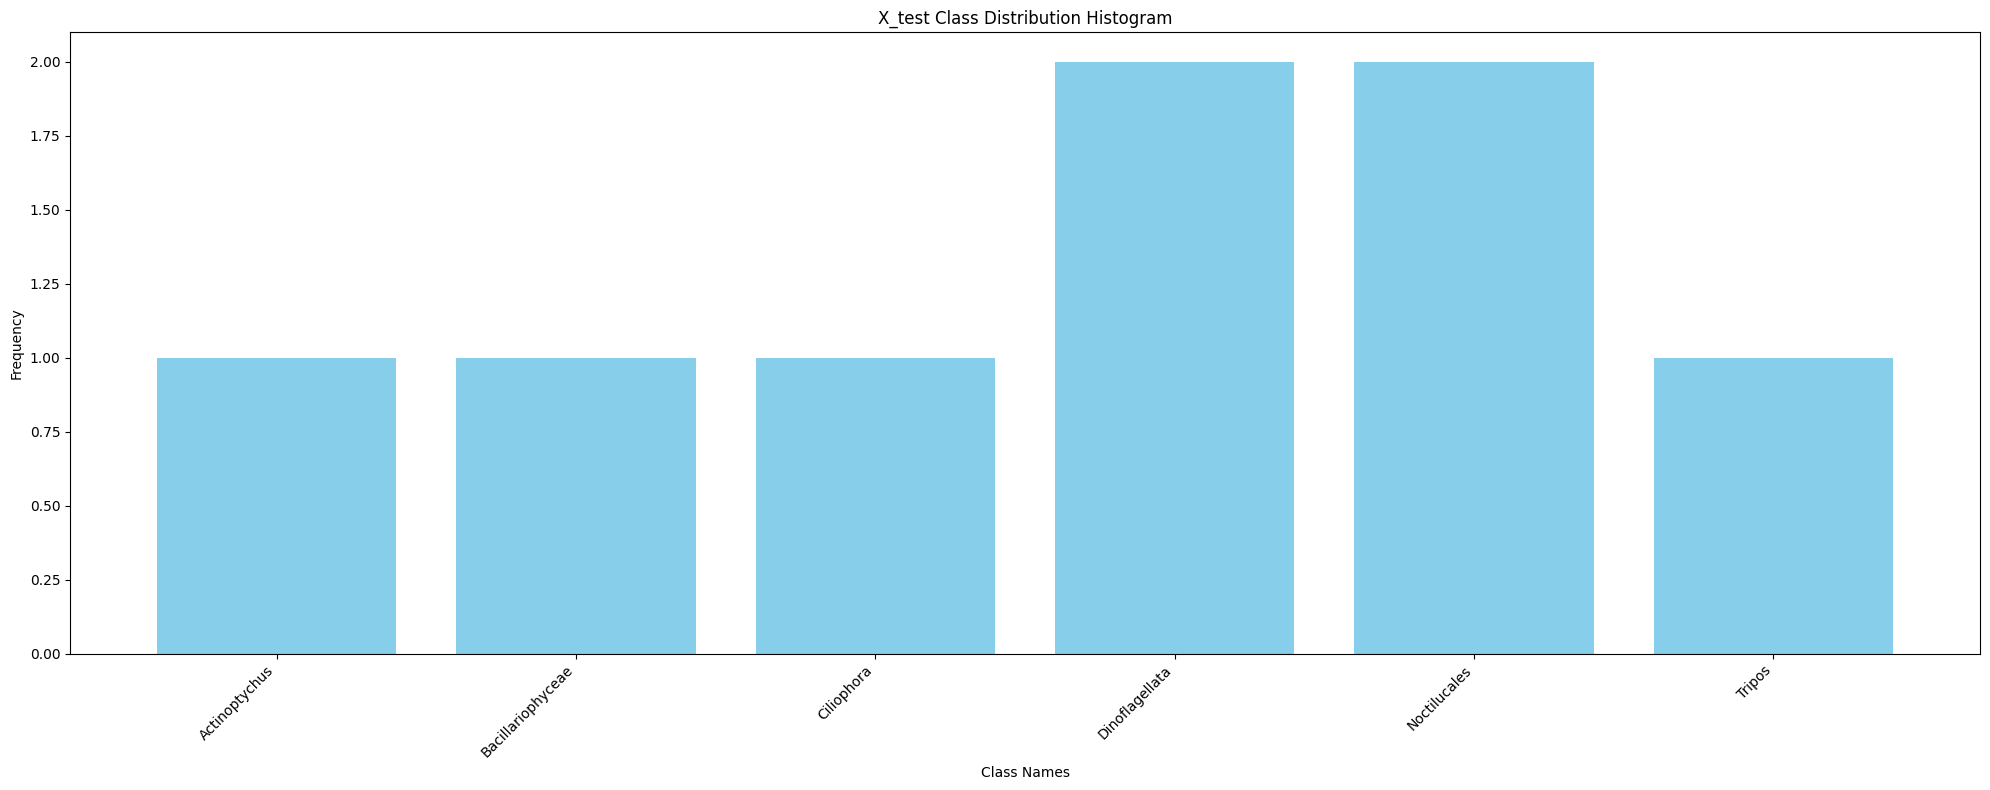

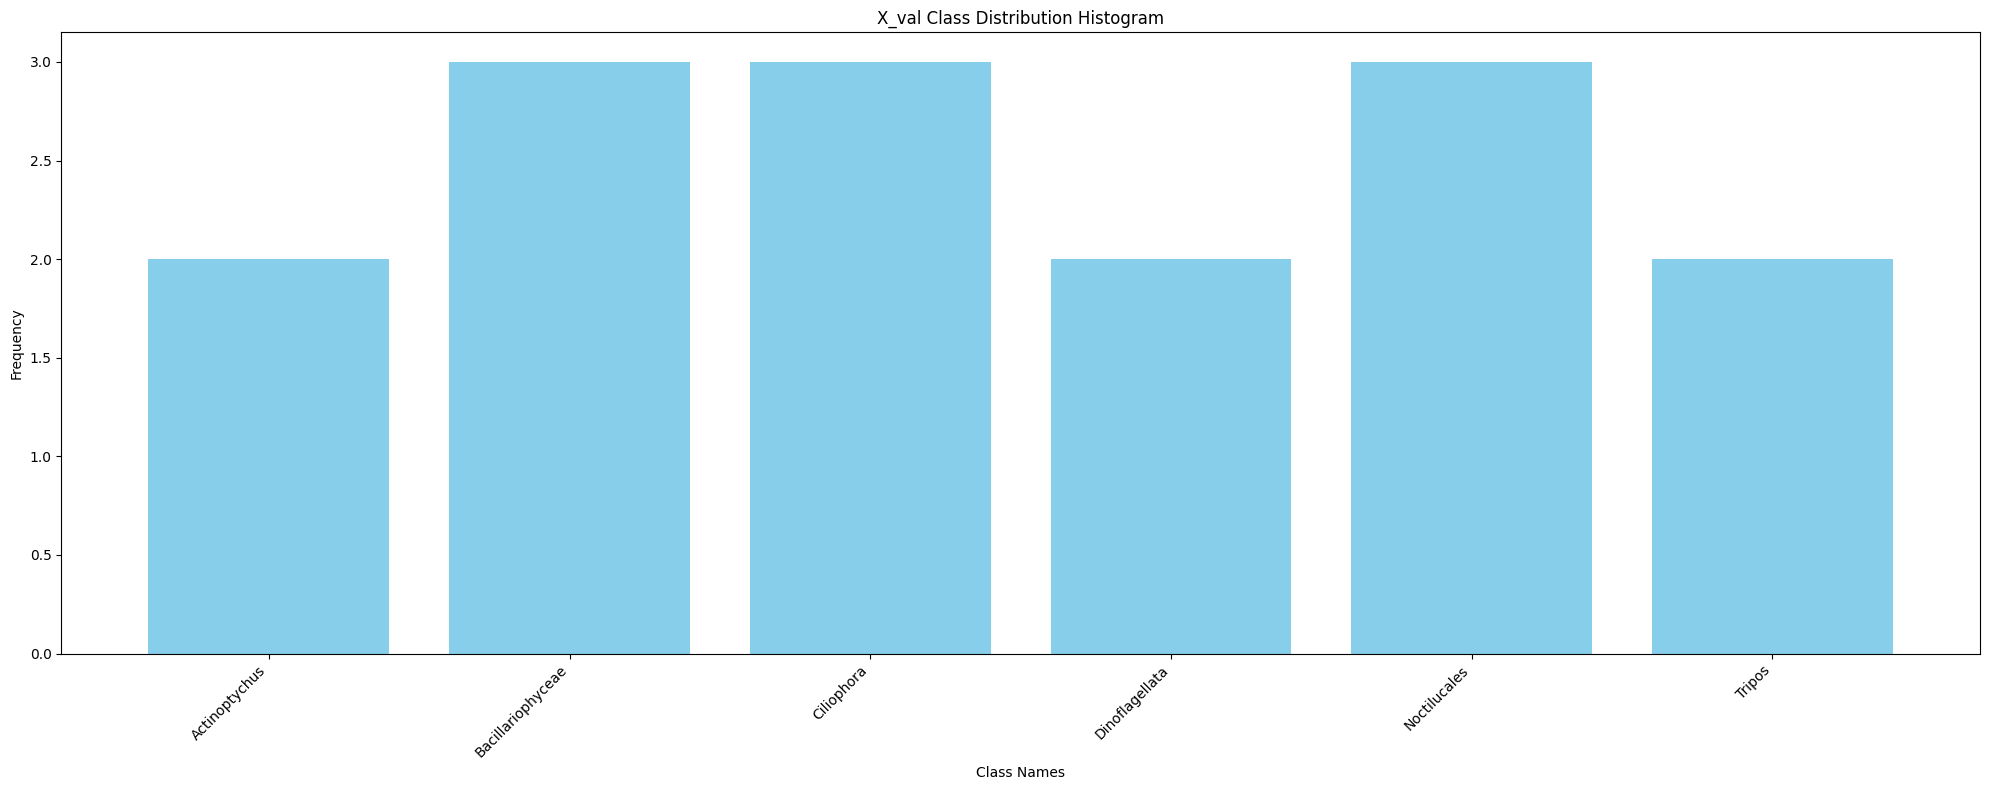

In [8]:
import os
# Concatenate the datasets
all_data = np.concatenate((X_train, X_test, X_val))

# Extract class names from file paths for all datasets
class_names_all = [os.path.basename(os.path.dirname(path)) for path in all_data]

# Count occurrences of each class for all datasets
class_counts_all = Counter(class_names_all)

# Extract class names and counts for all datasets
classes_all = list(class_counts_all.keys())
counts_all = list(class_counts_all.values())

# Plot histogram for all datasets combined
plt.figure(figsize=(20, 8))
plt.bar(classes_all, counts_all, color='skyblue')
plt.xlabel('Class Names')
plt.ylabel('Frequency')
plt.title('Total Class Distribution Histogram')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# Plot histogram for each dataset separately
datasets = {'X_train': X_train, 'X_test': X_test, 'X_val': X_val}
for dataset_name, dataset in datasets.items():
    class_names = [os.path.basename(os.path.dirname(path)) for path in dataset]
    class_counts = Counter(class_names)
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure(figsize=(20, 8))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Class Names')
    plt.ylabel('Frequency')
    plt.title(f'{dataset_name} Class Distribution Histogram')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()


Max Training: 18.0
Min Training: 0.0
Mean Training: 5.466666666666667
Median Training: 0.0


Max Validation: 3.0
Min Validation: 0.0
Mean Validation: 1.0
Median Validation: 0.0




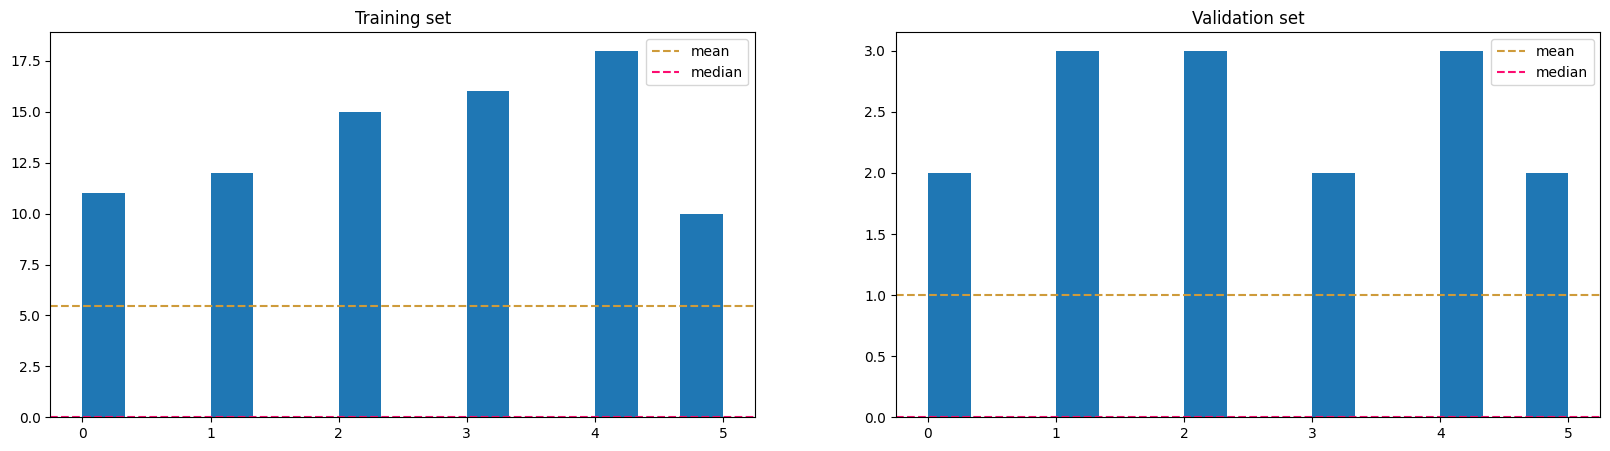

In [9]:
# Define some parameters
log_scale = False
show_names = False

# Plot the histograms
fig, axs = plt.subplots(1, 2, figsize=(20,5))

def plot_hist(ax, y, set_name=''):
    n, bins, patches = ax.hist(y, bins=len(class_names), log=log_scale)
    mean, med = np.mean(n), np.median(n)
    ax.axhline(mean, linestyle= '--', color='#ce9b3b', label='mean')
    ax.axhline(med, linestyle= '--', color='#fc0c70', label='median')
    ax.set_title('{} set'.format(set_name))
    ax.legend()
    if show_names:
        ax.set_xticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation='vertical')

    print('Max {}: {}'.format(set_name, np.amax(n)))
    print('Min {}: {}'.format(set_name, np.amin(n)))
    print('Mean {}: {}'.format(set_name, mean))
    print('Median {}: {}'.format(set_name, med))
    print('\n')

plot_hist(axs[0], y_train, set_name='Training')

axs[1].set_title('Validation set')
if y_val is not None:
    plot_hist(axs[1], y_val, set_name='Validation')


So if your dataset is **very** imbalanced you can consider setting the `use_class_weights` to `True` to compensate for this imbalance during the training.

## 1.2 Distribution of image sizes
**Relevant parameters:** `im_size`

We can visualize how the sizes of your images are tipically distributed in case you want to use a bigger image size resolution than the default.

In [10]:
# Load all images and retrieve their shapes
height, width = [], []
for img_path in tqdm(X_train):
    img = load_image(img_path)
    w, h, channels = img.shape
    width.append(w)
    height.append(h)


100%|██████████| 82/82 [00:00<00:00, 4487.47it/s]


Max Heights: 503
Min Heights: 35
Mean Heights: 94.6
Median Heights: 69.5
Heights 5th percentile: 40.15


Max Widths: 555
Min Widths: 39
Mean Widths: 110.9
Median Widths: 79.0
Widths 5th percentile: 44.35


Max Combined: 555
Min Combined: 35
Mean Combined: 102.8
Median Combined: 74.0
Combined 5th percentile: 43.0




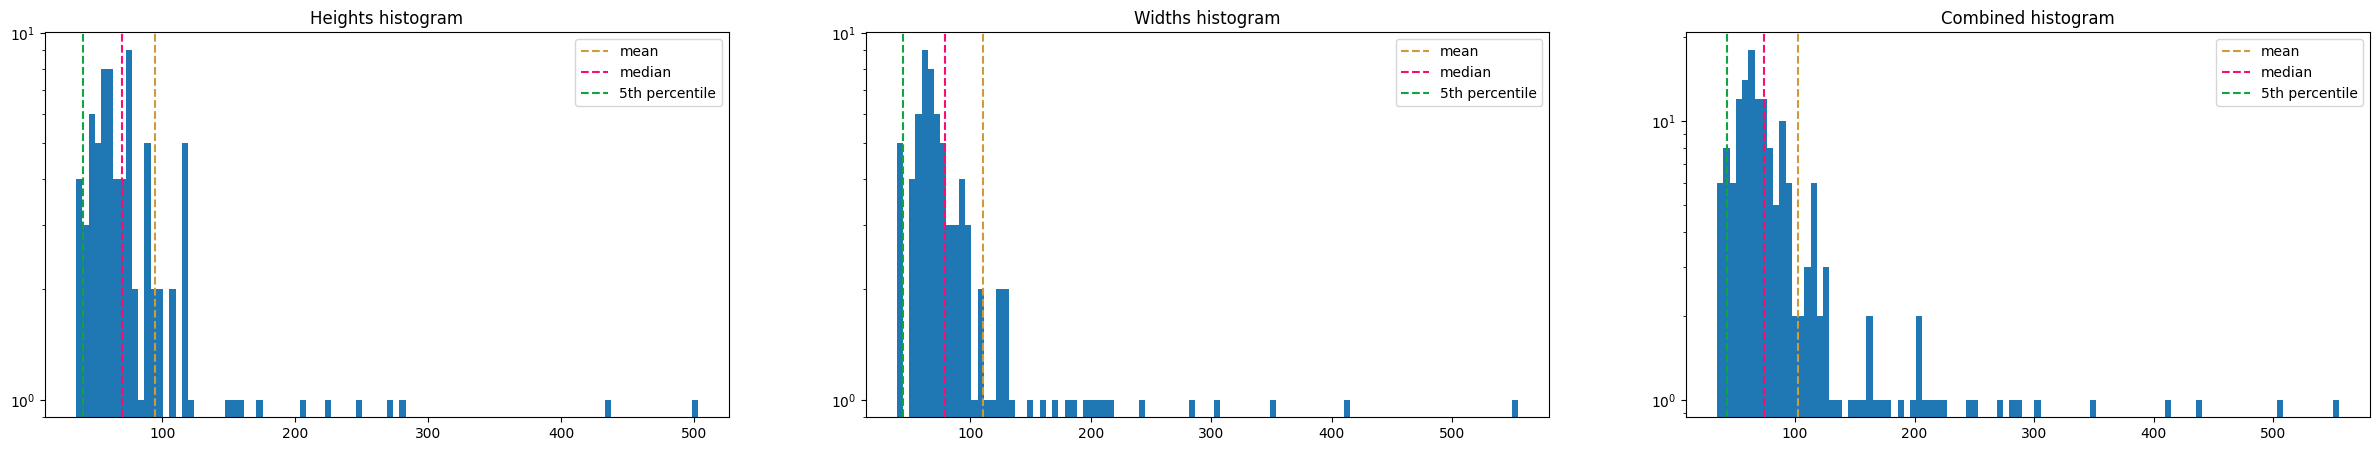

In [11]:
# Define some parameters
bins = 100
log_scale = True
lower_percentile = 5

def plot_hist(ax, values, set_name=''):
    
    # Print some stats
    mean, med, per = np.mean(values), np.median(values), np.percentile(values, lower_percentile)

    print('Max {}: {}'.format(set_name, np.amax(values)))
    print('Min {}: {}'.format(set_name, np.amin(values)))
    print('Mean {}: {:.1f}'.format(set_name, mean))
    print('Median {}: {}'.format(set_name, med))
    print('{} {}th percentile: {}'.format(set_name, lower_percentile, per))
    print('\n')
      
    # Plot the histogram
    ax.hist(values, bins=bins, log=log_scale)
    ax.set_title('{} histogram'.format(set_name))
    ax.axvline(mean, linestyle= '--', color='#ce9b3b', label='mean')
    ax.axvline(med, linestyle= '--', color='#fc0c70', label='median')
    ax.axvline(per, linestyle= '--', color='#0ea541', label='{}th percentile'.format(lower_percentile))
    ax.legend()

    
fig, axs = plt.subplots(1, 3, figsize=(30,5))
axs = axs.flatten()

plot_hist(axs[0], height, set_name='Heights')
plot_hist(axs[1], width, set_name='Widths')
plot_hist(axs[2], height + width, set_name='Combined')


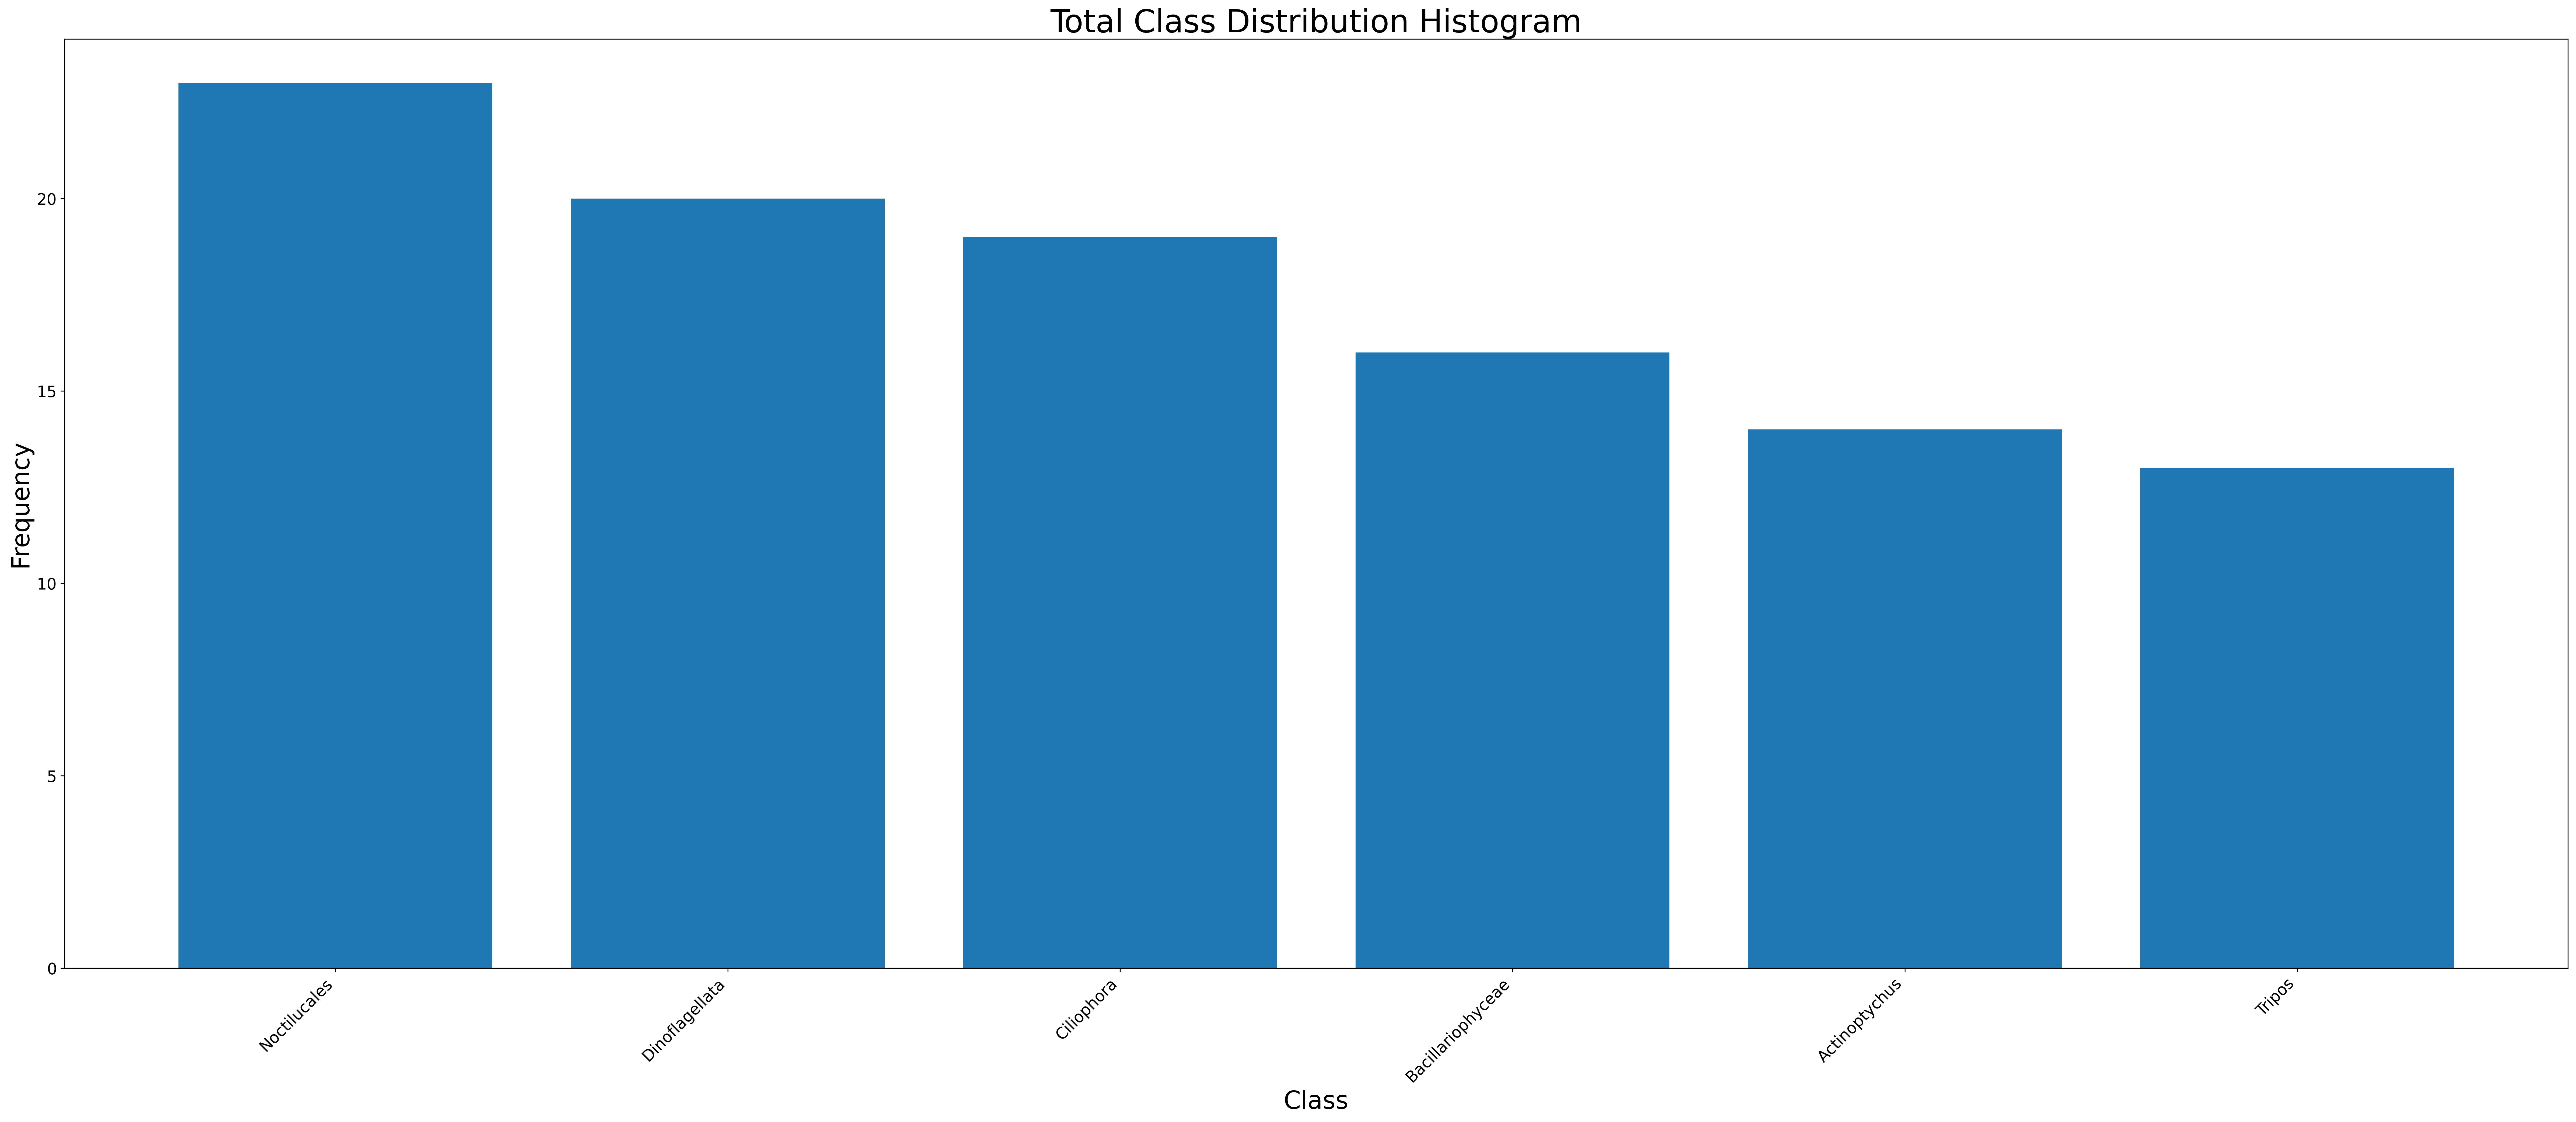

Exported: class_histogram_sorted.png and class_histogram_sorted.pdf


In [12]:
import os
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# ---- CONCAT + COUNT ----
all_data = np.concatenate((X_train, X_test, X_val))
class_names_all = [os.path.basename(os.path.dirname(path)) for path in all_data]
class_counts_all = Counter(class_names_all)

# Sort by count (descending)
classes_all, counts_all = zip(
    *sorted(class_counts_all.items(), key=lambda x: x[1], reverse=True)
)

# ---- HIGH QUALITY FIGURE ----
plt.figure(figsize=(32, 14), dpi=300)  # extremely high quality export

plt.bar(classes_all, counts_all)

# BIG FONTS
plt.xlabel('Class', fontsize=22)
plt.ylabel('Frequency', fontsize=22)
plt.title('Total Class Distribution Histogram', fontsize=28)

# READABLE X-AXIS
plt.xticks(rotation=45, ha='right', fontsize=14)

plt.yticks(fontsize=14)

plt.tight_layout()

# ---- EXPORT ----
plt.savefig("class_histogram_sorted.png", dpi=300, bbox_inches='tight')
plt.savefig("class_histogram_sorted.pdf", dpi=300, bbox_inches='tight')  # vector quality

plt.show()

print("Exported: class_histogram_sorted.png and class_histogram_sorted.pdf")


So after examining these plots and stats you can consider adapting the parameter `im_size` to better suit your usecase (maybe to a value in between the `Min combined` and the `Combined 5th percentile`).

When **increasing** this parameter from the default value you have to consider that:
* you keep more details in the image so the accuracy of the model *might* (or might not) increase.
* bigger images size means longer training and inference times
* bigger images means more model parameters. So it is possible to that model becomes too big to be trained on a GPU. 